## Raport 2
### Komputerowe symulacje procesów stochastycznych

Autorzy
* Krzysztof Dobrzański (242504)
* Bartosz Michalak (268429)

In [244]:
import numpy as np
import math
from scipy.stats import linregress, wasserstein_distance
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit

np.random.seed(42)

# shortcut for making np.arrays
def V(*args):
    return np.array(args, dtype=float)

### Generowanie losowego wektora stabilnego na podstawie miary spektralnej

Korzystamy ze wzoru (zakładając, że $\alpha \neq 1$):
$$\mathbf{X} \stackrel{d}{=} \sum_{j=1}^{m} \gamma_j^{1/\alpha} Z_j \mathbf{s}_j,$$
gdzie $Z_j \sim S_\alpha(1, 1, 0)$ to niezależne, całkowicie asymetryczne jednowymiarowe zmienne stabilne.

In [245]:
# @njit(parallel=True)
def get_random_a_stable_vec(alpha, beta, gamma, delta, size):
    theta = np.random.uniform(size=size) * math.pi - math.pi/2
    W = np.random.exponential(size=size)

    if alpha == 1:
        Z = 2/math.pi * ( (math.pi/2 + beta*theta)*np.tan(theta) - beta*np.log((math.pi/2 * W*np.cos(theta)) / (math.pi/2 + beta*theta)) )
        return gamma*Z + (delta + beta * 2/math.pi * gamma * np.log(gamma))
    else:
        theta_0 = np.arctan(beta*np.tan(math.pi*alpha/2))/alpha
        Z = np.sin(alpha*(theta_0 + theta)) / ((np.cos(alpha*theta_0)*np.cos(theta))**(1/alpha)) * ( np.cos(alpha*theta_0 + (alpha - 1)*theta) / W )**((1 - alpha)/alpha)
        return gamma*Z + delta


# @njit
def get_random_a_stable_vec_spectral(a, sp_angles, sp_weights, delta):
    sp_points = [np.array(V(math.cos(angle), math.sin(angle))) for angle in sp_angles]
    a_inv = 1.0/a
    res = np.zeros_like(delta, np.float64)
    
    for i in range(0, len(sp_angles)):
        res += (sp_weights[i]**a_inv) * sp_points[i] * get_random_a_stable_vec(a, 1, 1, 0, 1)
    
    return res + delta

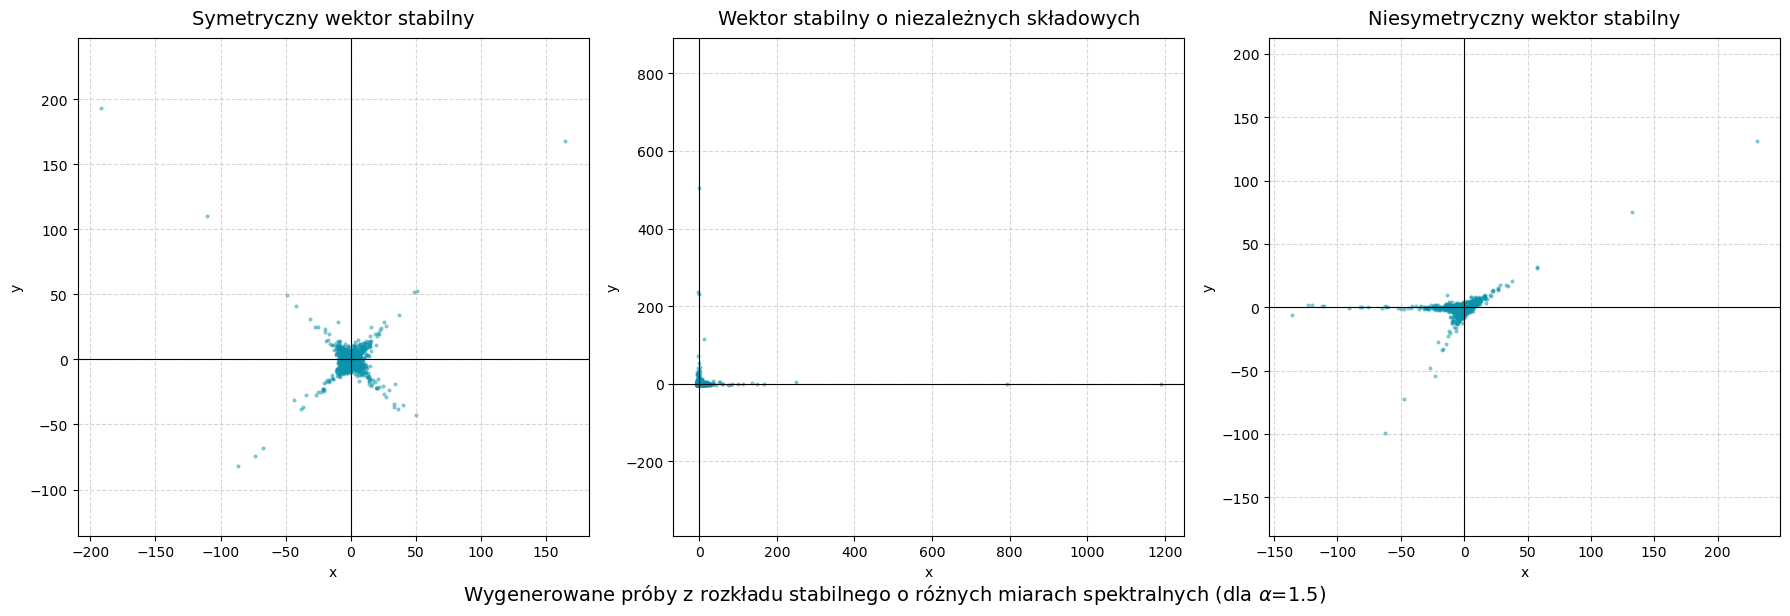

In [246]:
alpha = 1.5
proc_sample_count = 5000

angles = []

angles.append([np.pi/4 + i/2*np.pi for i in range(0, 4)])
weights = [1.0]*4

x_symetrical = np.array([get_random_a_stable_vec_spectral(alpha, angles[-1], weights, V(0.0, 0.0)) for _ in range(0, proc_sample_count)])

# independent - points only on OX and OY
angles.append([0, np.pi/2])
weights = [2.0, 1.0]

x_independent = np.array([get_random_a_stable_vec_spectral(alpha, angles[-1], weights, V(0.0, 0.0)) for _ in range(0, proc_sample_count)])

# "random" points
angles.append([np.pi/6, np.pi, 4*np.pi/3])
weights = [1.0, 2.5, 0.5]

x_asymetrical = np.array([get_random_a_stable_vec_spectral(alpha, angles[-1], weights, V(0.0, 0.0)) for _ in range(0, proc_sample_count)])

###################


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def style_axis(ax, title):
    ax.set_title(title, fontsize=14, pad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal') 

axes[0].scatter(x_symetrical[:, 0], x_symetrical[:, 1], s=4, alpha=0.4, color="#0c92aa")
style_axis(axes[0], f"Symetryczny wektor stabilny")

axes[1].scatter(x_independent[:, 0], x_independent[:, 1], s=4, alpha=0.4, color="#0c92aa")
style_axis(axes[1], f"Wektor stabilny o niezależnych składowych")

axes[2].scatter(x_asymetrical[:, 0], x_asymetrical[:, 1], s=4, alpha=0.4, color='#0c92aa')
style_axis(axes[2], f"Niesymetryczny wektor stabilny")

plt.tight_layout()
fig.suptitle(
    f"Wygenerowane próby z rozkładu stabilnego o różnych miarach spektralnych (dla $\\alpha$={alpha})",
    y=0.02,
    fontsize=14
)
plt.show()

In [247]:
def get_rand_normal_vec(mean, cov, n_samples=1):
    dims = mean.shape[0]
    z = np.random.randn(n_samples, dims)
    A = np.linalg.cholesky(cov)

    return mean + z @ A.T


def get_rand_subgaussian(alpha, cov, n_samples):
    A = get_random_a_stable_vec(alpha/2, beta=1.0, gamma=1.0, delta=0.0, size=n_samples)
    A = np.maximum(A, 0)
    
    G = get_rand_normal_vec(V(0, 0), cov, n_samples)
    X = np.sqrt(A)[:, np.newaxis] * G
    return X

### Generowanie wektora losowego sub-gaussowskiego

Losowym wektorem sub-gaussowskim jest wektor X, taki, że:

$$\mathbf{X} = A^{1/2} \mathbf{G},$$
gdzie $\mathbf{G} \sim \mathcal{N}(0, \Sigma)$ to dwuwymiarowy wektor z rozkładu normalnego, a $A \sim S_{\alpha/2}(1, 1, 0)$ to dodatnia zmienna stabilna, niezależna od $\mathbf{G}$.

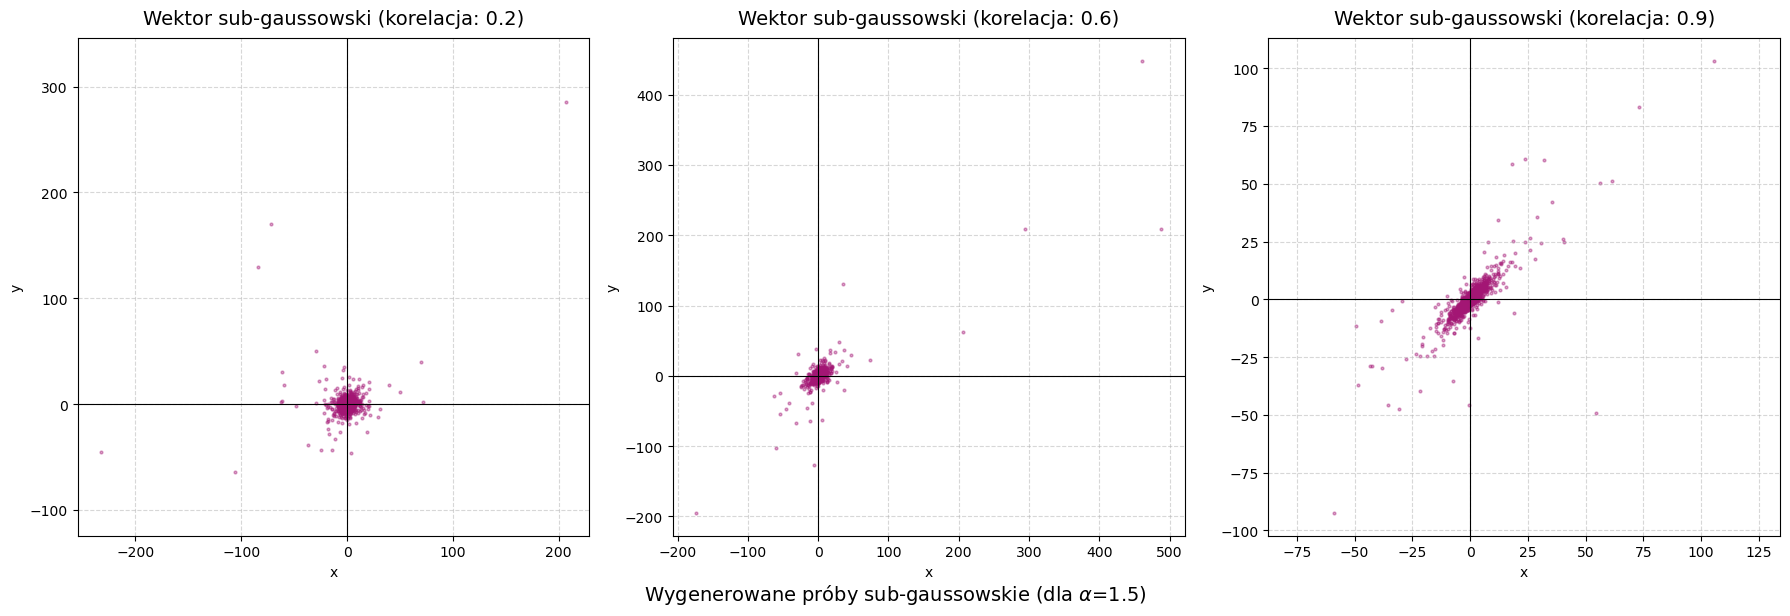

In [248]:
proc_sample_count = 5000

x_subgaussian = []
corr_values = [0.2, 0.6, 0.9]

for correlation in corr_values:
    cov_matrix = [[1.0, correlation], 
                  [correlation, 1.0]]

    x_subgaussian.append(get_rand_subgaussian(alpha, cov_matrix, proc_sample_count))
x_subgaussian = np.array(x_subgaussian)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def style_axis(ax, title):
    ax.set_title(title, fontsize=14, pad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.axis('equal') 

axes[0].scatter(x_subgaussian[0, :, 0], x_subgaussian[0, :, 1], s=4, alpha=0.4, color="#a31674")
style_axis(axes[0], f"Wektor sub-gaussowski (korelacja: {corr_values[0]})")

axes[1].scatter(x_subgaussian[1, :, 0], x_subgaussian[1, :, 1], s=4, alpha=0.4, color="#a31674")
style_axis(axes[1], f"Wektor sub-gaussowski (korelacja: {corr_values[1]})")

axes[2].scatter(x_subgaussian[2, :, 0], x_subgaussian[2, :, 1], s=4, alpha=0.4, color="#a31674")
style_axis(axes[2], f"Wektor sub-gaussowski (korelacja: {corr_values[2]})")

plt.tight_layout()
fig.suptitle(
    f"Wygenerowane próby sub-gaussowskie (dla $\\alpha$={alpha})",
    y=0.02,
    fontsize=14
)
plt.show()

### Estymacja parametru alfa oraz miary spektralnej

In [249]:
def estimate_alpha_cf(X, t_max=1.0, num_t=50):
    t_vals = np.linspace(0.01, t_max, num_t)
    phi_n_abs = np.array([np.abs(np.mean(np.exp(1j * t * X))) for t in t_vals])
    valid_mask = (phi_n_abs > 0) & (phi_n_abs < 1)
    if not np.any(valid_mask): return np.nan
    
    y = np.log(-np.log(phi_n_abs[valid_mask]))
    x = np.log(t_vals[valid_mask])
    slope, _, _, _, _ = linregress(x, y)
    return np.clip(slope, 0.0, 2.0)
    
    
def estimate_spectral_measure(proc_vals, threshold = 10.0):
    norms = np.linalg.norm(proc_vals, axis=1)
    extreme_vals = proc_vals[norms > threshold]
    angles = np.arctan2(extreme_vals[:, 1], extreme_vals[:, 0])
    
    return np.mod(angles, 2 * np.pi)

Prawdziwe alpha: 1.5
Estymacja alpha:
Symetryczny: 1.546


Niezależne składowe: 1.493
Niesymetryczny, zależny: 1.439


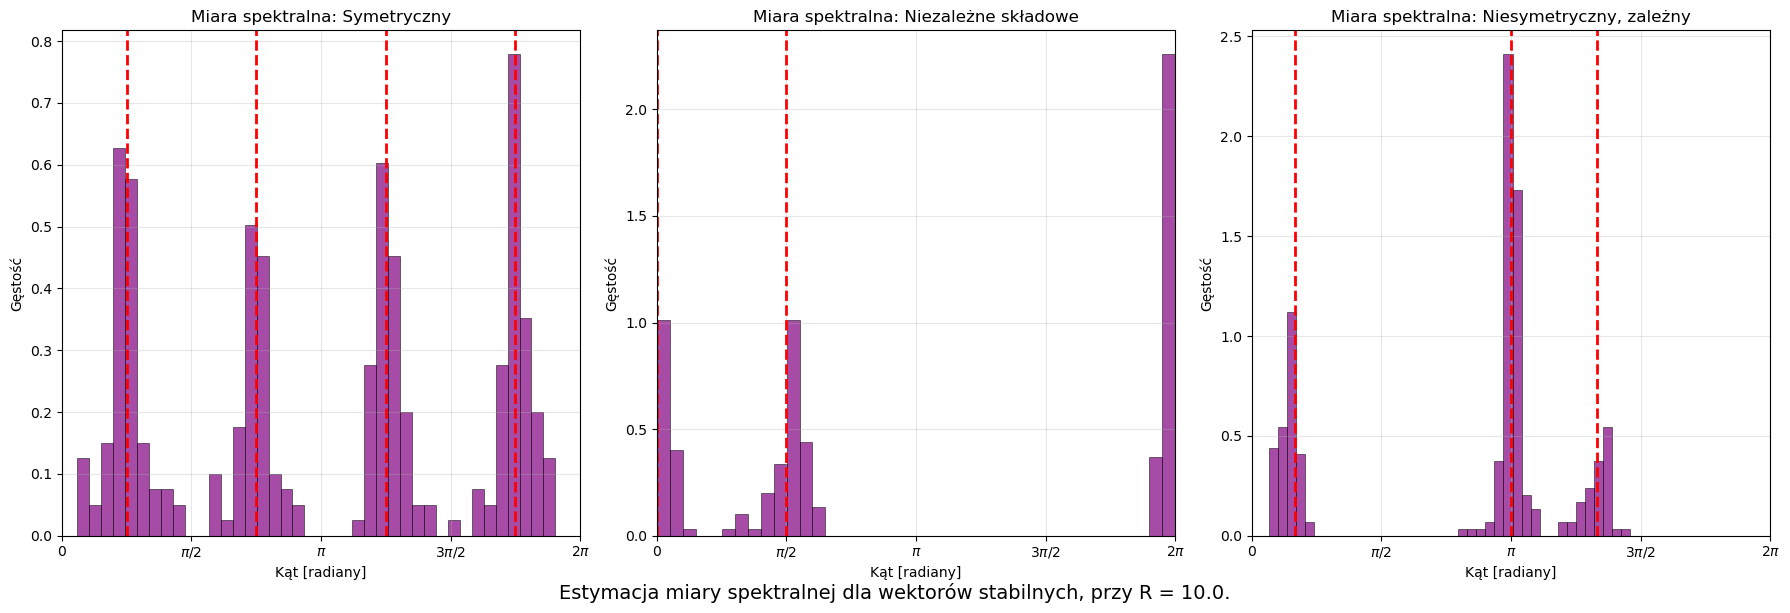

Estymacja alpha:
Sub-gaussowski (korelecja = 0.2): 1.521
Sub-gaussowski (korelecja = 0.6): 1.461
Sub-gaussowski (korelecja = 0.9): 1.523


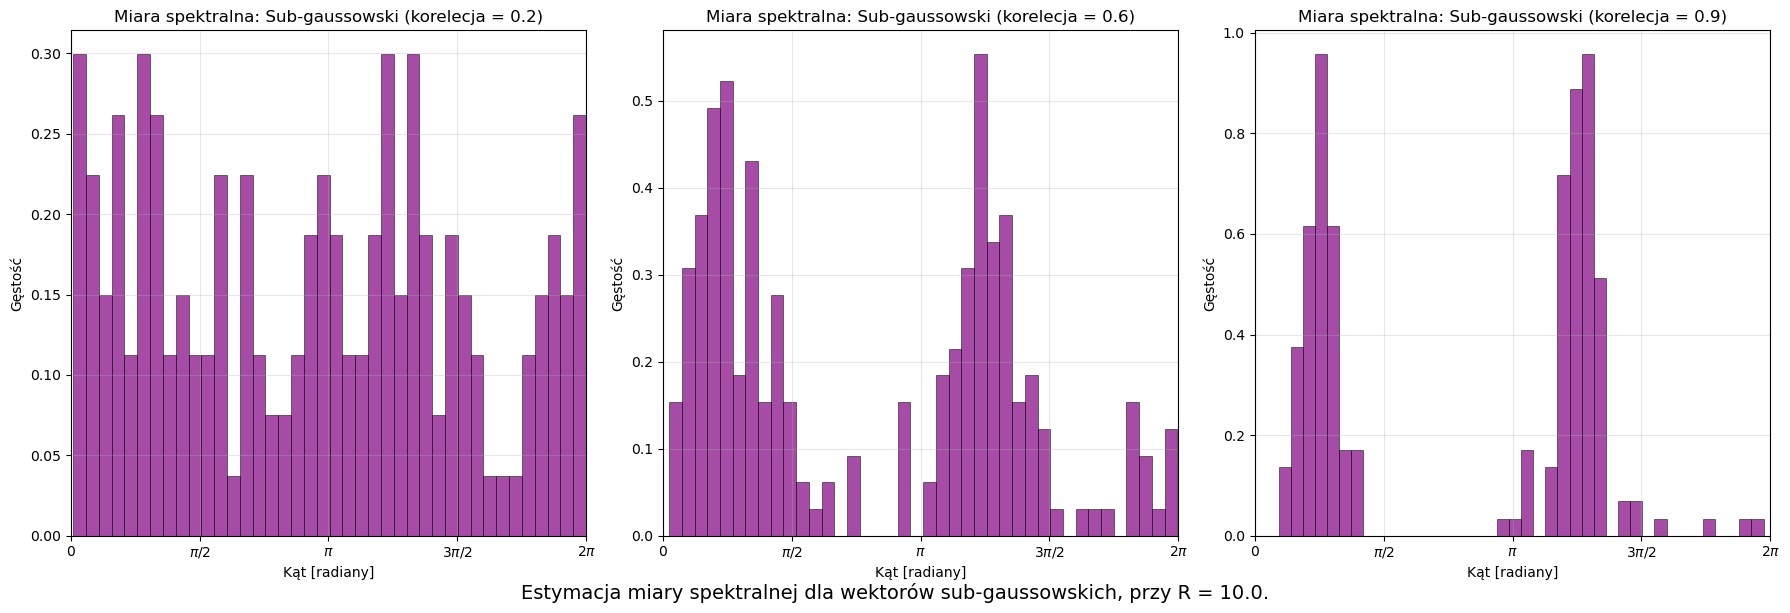

In [250]:
threshold = 10.0

a_stable_proc_data = {
    "Symetryczny": x_symetrical,
    "Niezależne składowe": x_independent,
    "Niesymetryczny, zależny": x_asymetrical,
}

subg_proc_data = {
    f"Sub-gaussowski (korelecja = {corr_values[0]})": x_subgaussian[0],
    f"Sub-gaussowski (korelecja = {corr_values[1]})": x_subgaussian[1],
    f"Sub-gaussowski (korelecja = {corr_values[2]})": x_subgaussian[2],
}

print(f"Prawdziwe alpha: {alpha}")

#################
# a-stable
#################

print("Estymacja alpha:")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, (name, proc_vals) in enumerate(a_stable_proc_data.items()):
    alpha_est = estimate_alpha_cf(proc_vals)
    print(f"{name}: {alpha_est:.3f}")
    
    angles_est = estimate_spectral_measure(proc_vals, threshold)
    
    ax = axes[idx]

    ax.hist(angles_est, bins=40, density=True, color='purple', alpha=0.7, edgecolor='black', linewidth=0.5)
    for angle in angles[idx]:
        ax.axvline(angle, color='red', linestyle='--', linewidth=2)
    ax.set_title(f"Miara spektralna: {name}")
    ax.set_xlabel("Kąt [radiany]")
    ax.set_ylabel("Gęstość")
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.tight_layout()
fig.suptitle(
    f"Estymacja miary spektralnej dla wektorów stabilnych, przy R = {threshold}.",
    y=0.02,
    fontsize=14
)
plt.show()

#################
# Sub-gaussian
#################

print("Estymacja alpha:")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for idx, (name, proc_vals) in enumerate(subg_proc_data.items()):
    alpha_est = estimate_alpha_cf(proc_vals)
    print(f"{name}: {alpha_est:.3f}")
    
    angles_est = estimate_spectral_measure(proc_vals, threshold)
    
    ax = axes[idx]

    ax.hist(angles_est, bins=40, density=True, color='purple', alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.set_title(f"Miara spektralna: {name}")
    ax.set_xlabel("Kąt [radiany]")
    ax.set_ylabel("Gęstość")
    ax.grid(True, alpha=0.3)
    
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])

plt.tight_layout()
fig.suptitle(
    f"Estymacja miary spektralnej dla wektorów sub-gaussowskich, przy R = {threshold}.",
    y=0.02,
    fontsize=14
)
plt.show()

### Estymacja funkcji charakterystycznej

Empiryczna funkcja charakterystyczna (ECF) dla próbki $\mathbf{x}_1, \dots, \mathbf{x}_N$ jest zdefiniowana jako średnia:$$\hat{\phi}(\mathbf{t}) = \frac{1}{N} \sum_{k=1}^N \exp(i \langle \mathbf{t}, \mathbf{x}_k \rangle).$$
Dla teoretycznego rozkładu sub-gaussowskiego z wektorem kowariancji $\Sigma$, funkcja charakterystyczna ma postać zamkniętą:
  $$\phi_{sub}(\mathbf{t}) = \exp \left( - \left( \frac{1}{2} \mathbf{t}^T \Sigma \mathbf{t} \right)^{\alpha/2} \right).$$

### Estymacja funkcji charakterystycznej

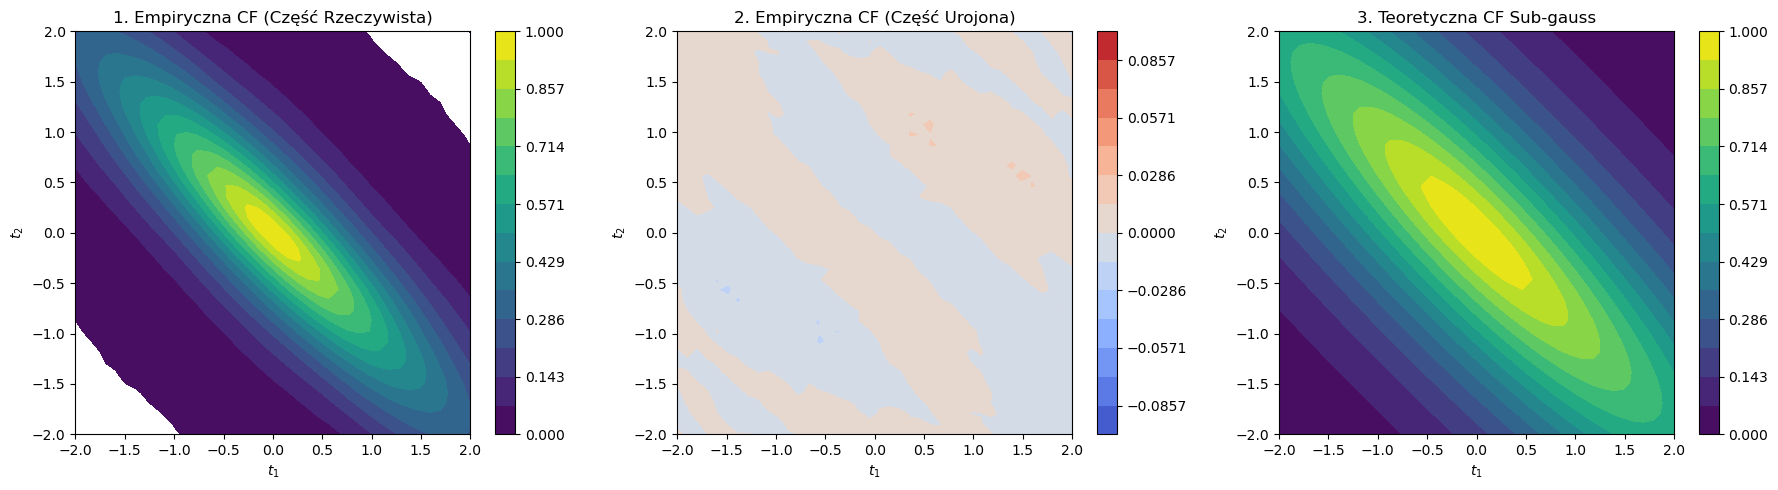

MSE między wartością wyestymowaną, a teoretyczną: 0.059214


In [251]:
def empirical_cf_2d(X, T1, T2):
    ECF = np.zeros_like(T1, dtype=complex)
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            t = np.array([T1[i,j], T2[i,j]])
            ECF[i,j] = np.mean(np.exp(1j * np.dot(X, t)))
    return ECF

def theoretical_cf_subgaussian(T1, T2, alpha, cov_matrix):
    CF = np.zeros_like(T1, dtype=float)
    cov = np.array(cov_matrix)
    for i in range(T1.shape[0]):
        for j in range(T1.shape[1]):
            t = np.array([T1[i,j], T2[i,j]])
            quadratic_form = 0.5 * np.dot(t.T, np.dot(cov, t))
            CF[i,j] = np.exp(- (quadratic_form)**(alpha/2))
    return CF

grid_points = np.linspace(-2, 2, 40)
T1, T2 = np.meshgrid(grid_points, grid_points)

ECF_subg = empirical_cf_2d(x_subgaussian[2], T1, T2)
CF_theo = theoretical_cf_subgaussian(T1, T2, alpha, cov_matrix)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ECF - real
levels = np.linspace(0, 1, 15)
c1 = axes[0].contourf(T1, T2, np.real(ECF_subg), levels=levels, cmap='viridis')
axes[0].set_title("1. Empiryczna CF (Część Rzeczywista)")
axes[0].set_xlabel("$t_1$")
axes[0].set_ylabel("$t_2$")
fig.colorbar(c1, ax=axes[0])

# ECF - imaginary
levels_imag = np.linspace(-0.1, 0.1, 15) 
c2 = axes[1].contourf(T1, T2, np.imag(ECF_subg), levels=levels_imag, cmap='coolwarm')
axes[1].set_title("2. Empiryczna CF (Część Urojona)")
axes[1].set_xlabel("$t_1$")
axes[1].set_ylabel("$t_2$")
fig.colorbar(c2, ax=axes[1])

# Theoretical ECF
c3 = axes[2].contourf(T1, T2, CF_theo, levels=levels, cmap='viridis')
axes[2].set_title("3. Teoretyczna CF Sub-gauss")
axes[2].set_xlabel("$t_1$")
axes[2].set_ylabel("$t_2$")
fig.colorbar(c3, ax=axes[2])

plt.tight_layout()
plt.show()

mse = np.mean((np.real(ECF_subg) - CF_theo)**2)
print(f"MSE między wartością wyestymowaną, a teoretyczną: {mse:.6f}")

### Miara kodyferencji

Kodiferencja $\tau$ to miara zależności dla rozkładów z grubymi ogonami (gdzie kowariancja może nie istnieć). Oblicza się ją ze wzoru:
$$\tau(X_1, X_2) = \ln \phi(1, -1) - \ln \phi(1, 0) - \ln \phi(0, -1).$$
Zauważamy, że dla części rzeczywistej:
$$\text{Re}(\tau) = \ln |\phi(1, -1)| - \ln |\phi(1, 0)| - \ln |\phi(0, -1)|.$$
Dla miary spektralnej dyskretnej z Zadania 1 (masy $\gamma_j$ na kątach $\theta_j$), moduł teoretycznej funkcji charakterystycznej wynosi:
$$\ln |\phi(t_1, t_2)| = - \sum_{j} \gamma_j |t_1 \cos\theta_j + t_2 \sin\theta_j|^\alpha.$$
Podstawiając do tego wektory $t=(1,-1)$, $t=(1,0)$ oraz $t=(0,-1)$, otrzymujemy:
$$\tau_{teor} = \sum_{j} \gamma_j \left( |\cos\theta_j|^\alpha + |-\sin\theta_j|^\alpha - |\cos\theta_j - \sin\theta_j|^\alpha \right).$$


In [258]:
def estimate_codifference_empirical(X, Y):
    return (np.log(np.mean( np.exp(1j*(X - Y)) )) - np.log(np.mean( np.exp(1j*X) )) - np.log(np.mean( np.exp(-1j*Y) ))).real


def theoretical_codifference_discrete(alpha, angles, weights):
    angles = np.array(angles)
    weights = np.array(weights)
    
    # \sum \gamma_j ( |cos|^\alpha + |-sin|^\alpha - |cos - sin|^\alpha )
    term1 = np.abs(np.cos(angles))**alpha
    term2 = np.abs(-np.sin(angles))**alpha
    term3 = np.abs(np.cos(angles) - np.sin(angles))**alpha
    
    tau_theo = np.sum(weights * (term1 + term2 - term3))
    return tau_theo


measures = {
    "Niezależne": {"angles": [0, np.pi/2], "weights": [1.0, 1.0]},
    "Symetryczne": {"angles": [np.pi/4, 3*np.pi/4, 5*np.pi/4, 7*np.pi/4], "weights": [1.0, 1.0, 1.0, 1.0]},
    "Niesymetryczne (zależne)": {"angles": [np.pi/6, np.pi, 4*np.pi/3], "weights": [2.0, 1.5, 0.5]}
}

alphas_to_test = [0.4, 0.6, 0.8, 1.2, 1.5, 1.8]
n_samples = 20000

print(f"{'Miara Spektralna':<26} | {'Alpha':<5} | {'Tau (empiryczne)':<16} | {'Tau (teoretyczne)':<12}")
print("-" * 68)

for alpha in alphas_to_test:
    for name, params in measures.items():
        angles = params["angles"]
        weights = params["weights"]
        
        tau_theo = theoretical_codifference_discrete(alpha, angles, weights)
        
        X = np.array([get_random_a_stable_vec_spectral(alpha, angles, weights, V(0.0, 0.0)) for _ in range(0, n_samples)])
        tau_emp = estimate_codifference_empirical(X[:,0], X[:,1])
        
        print(f"{name:<26} | {alpha:<5} | {tau_emp:>16.5f} | {tau_theo:>12.5f}")
    print("-" * 68)

Miara Spektralna           | Alpha | Tau (empiryczne) | Tau (teoretyczne)
--------------------------------------------------------------------
Niezależne                 | 0.4   |         -0.01317 |      0.00000
Symetryczne                | 0.4   |          4.76777 |      4.66701
Niesymetryczne (zależne)   | 0.4   |          2.33061 |      2.58245
--------------------------------------------------------------------
Niezależne                 | 0.6   |          0.01686 |      0.00000
Symetryczne                | 0.6   |          3.93417 |      4.03573
Niesymetryczne (zależne)   | 0.6   |          2.82517 |      2.57480
--------------------------------------------------------------------
Niezależne                 | 0.8   |         -0.00604 |      0.00000
Symetryczne                | 0.8   |          3.43933 |      3.42385
Niesymetryczne (zależne)   | 0.8   |          2.58528 |      2.54533
--------------------------------------------------------------------
Niezależne                 | 

Miara kodyferencji pozwala na skwantyfikowanie zależności w wektorach stabilnych. W naszych eksperymentach, wyraźnie widać wartości kodyferencji bliskie 0 dla niezależnych wektorów stabilnych. Co ciekawe, dla wektorów zależnych, symetrycznych, mimo użycia tej samej definicji spektralnej, kodyferencja maleje wraz ze wzrostem parametru alfa. Ten efekt nie jest wyraźnie widoczny dla wektorów zależnych, niesymetrycznych.

Zastanawiając się nad tą zależnością, rozpatrywaliśmy podany wcześniej wzór na tau teoretyczne:

$$\tau_{teor} = \sum_{j} \gamma_j \left( |\cos\theta_j|^\alpha + |-\sin\theta_j|^\alpha - |\cos\theta_j - \sin\theta_j|^\alpha \right).$$

Gdy $\alpha \to 2$,

$$\tau_{teor} \to \sum_{j} \gamma_j \left( |\cos\theta_j|^2 + |-\sin\theta_j|^2 - |\cos\theta_j - \sin\theta_j|^2 \right) = \sum_{j} \gamma_j \left( 2 \cos\theta_j \sin\theta_j \right) = 2 \sum_{j} \gamma_j \sin (2 \theta_j)$$

Wartość ta zależy więc od sumy ważonej sinusów podwójnych kątów użytych w definicji miary spektralnej. Ponieważ wektor ten jest symetryczny (ma równe wagi dla każdego punktu), szansa na wzajemne redukowanie się tych sinusów jest spora. Dodatko, podwojenie kąta powoduje "zbicie się" punktów - wybrane przez nas cztery punkty w mierze spektralnej redukują się efektywnie do dwóch (ponieważ dwa z nich wychodzą poza okres sinusa), co dodatkowo zwiększa szanse redukcji.

### Wybór R dla miary spektralnej

In [255]:
def find_optimal_R(alphas, angles_true, weights_true, n_samples=20000, R_grid=np.linspace(1, 50, 40)):
    weights_normalized = np.array(weights_true) / np.sum(weights_true)
    
    optimal_Rs = []
    distances_per_alpha = {}

    for alpha in alphas:
        print(f"Symulacja dla alpha = {alpha}...")
        
        X = np.array([get_random_a_stable_vec_spectral(alpha, angles_true, weights_true) for _ in range(0, n_samples)])
        
        distances = []
        valid_R_grid = []
        
        for R in tqdm(R_grid, leave=False):
            angles_est = estimate_spectral_measure(X, R)
            
            if len(angles_est) < 5:
                continue
            
            dist = wasserstein_distance(angles_est, angles_true, v_weights=weights_normalized)
            
            distances.append(dist)
            valid_R_grid.append(R)
            
        distances_per_alpha[alpha] = (valid_R_grid, distances)
        
        if len(distances) == 0:
            min_idx = np.argmin(distances)
            optimal_Rs.append(valid_R_grid[min_idx])
        else:
            optimal_Rs.append(np.nan)
            
    return optimal_Rs, distances_per_alpha

Zaproponowany przez nas algorytm wyboru optymalnego progu odcięcia (`R`) do estymacji funkcji charakterystycznej oparty został o odelgłość Wassersteina pomiędzy prawdziwymi punktami (kątami) miary spektralnej, a wyestymowanymi punktami (kątami). Odległość ta różni się od zwykłej odległości euklidesowej tym, że uwzględnia wagi dla punktów. Zwracana wartość wyrażenia `dist = wasserstein_distance(angles_est, angles_true, v_weights=weights_normalized)` jest skumulowaną odległością pomiędzy prawdziwymi i empirycznymi kątami, gdzie wagą dla każdego kąta jest ta sama waga, która użyta jest w definicji rozkładu stabilnego przez miarę spektralną.

Symulacja dla alpha = 1.2...


  0%|          | 9/4000 [00:00<00:47, 84.39it/s]

Symulacja dla alpha = 1.4...


Symulacja dla alpha = 1.6...


Symulacja dla alpha = 1.8...


Symulacja dla alpha = 1.9...


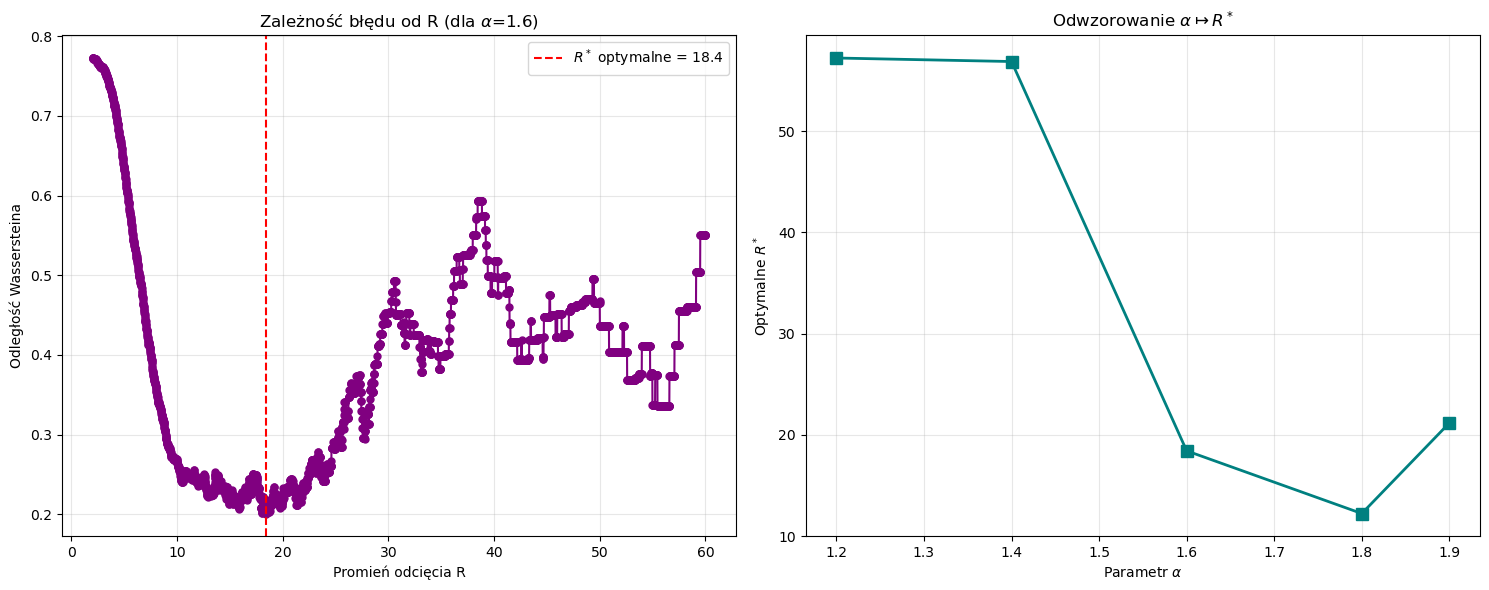

In [257]:
n_samples = 20000 
alphas_to_test = [1.2, 1.4, 1.6, 1.8, 1.9]

# "random" points
angles_test = [np.pi/6, np.pi, 5*np.pi/3] 
weights_test = [2.0, 1.5, 3.0]

R_values_to_test = np.linspace(2, 60, 4000)

R_stars, distances_dict = find_optimal_R (
    alphas_to_test, angles_test, weights_test, 
    n_samples=n_samples, R_grid=R_values_to_test
)

############

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

example_alpha = 1.6
r_grid, dists = distances_dict[example_alpha]
axes[0].plot(r_grid, dists, marker='o', markersize=5, linestyle='-', color='purple')
axes[0].set_title(f"Zależność błędu od R (dla $\\alpha$={example_alpha})")
axes[0].set_xlabel("Promień odcięcia R")
axes[0].set_ylabel("Odległość Wassersteina")

idx = alphas_to_test.index(example_alpha)
axes[0].axvline(R_stars[idx], color='red', linestyle='--', label=f"$R^*$ optymalne = {R_stars[idx]:.1f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(alphas_to_test, R_stars, marker='s', markersize=8, color='teal', linestyle='-', linewidth=2)
axes[1].set_title("Odwzorowanie $\\alpha \\mapsto R^*$")
axes[1].set_xlabel("Parametr $\\alpha$")
axes[1].set_ylabel("Optymalne $R^*$")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()